# Lightkurve Tutorial

In this tutorial, we will demonstrate the new `lightkurve` package, which you can read all about [here](http://docs.lightkurve.org/tutorials/). We will demonstrate the workflow of lightkurve for TESS data, and show off a few of our tools for planet detection.


## Table of Contents

* [1. Getting Started](#1.-Getting-Started)
* [2. Introduction](#2.-Introduction)
* [3. Lightkurve workflow](#3.-Lightkurve-workflow)
   * [3.1. Working with a TPF](#3.1-Working-with-a-TPF)
   * [3.2. Working with Light Curves](#3.2-Working-with-Light-Curves)
* [4. Making Simple Corrections to Light Curves](#4.-Making-simple-corrections-to-light-curves)
    * [4.1 Folding Light Curves](#4.1-Folding-Light-Curves)
    * [4.2 Stringing Commands Together](#4.2-Stringing-Commands-Together)
* [5. Converting Light Curves to Other Formats](#5.-Converting-light-curves-to-other-formats)
* [6. Searching for Targets](#6.-Searching-for-Targets)
    * [6.1 Radius Queries](#6.1-Radius-Queries)
    * [6.2 Obtaining TESS FFI Cut-outs](#6.2-Obtaining-TESS-FFI-Cut-outs)
    * [6.3 Stitching Light Curves](#6.3-Stitching-Light-Curves)
* [7. Periodograms](#7.-Periodograms)
    * [7.1 BLS Periodograms](#7.1-BLS-Periodograms)
    * [7.2 Interactively searching with BLS](#7.2-Interactively-searching-with-BLS)
* [8. Troubleshooting and Contributing](#8.-Troubleshooting-and-Contributing)
* [9. Flare Analysis](#9.-Flare-Analysis)
    * [9.1 Introduction to Stellar Flares](#9.1-Introduction-to-Stellar-Flares)
    * [9.2 Flare Detection](#9.2-Flare-Detection)
    * [9.3 Flare Characterization](#9.3-Flare-Characterization)
    * [9.4 Flare Rates and Equivalent Duration](#9.4-Flare-Rates-and-Equivalent-Duration)
    * [9.5 Visualizing Flares](#9.5-Visualizing-Flares)

## 1. Getting Started

If you would like to get started with this tutorial, we recommend you have the following installed:
* **lightkurve version 2.6.0 or higher** (use `pip install --upgrade lightkurve`)
* Standard scientific Python stack: numpy, pandas, matplotlib, scipy, astropy

This notebook is designed for anyone interested in analyzing light curves from NASA's TESS, Kepler, or K2 missions. Whether you're looking for exoplanets, stellar flares, variable stars, or other time-domain phenomena, lightkurve provides the tools you need.

Once you have looked through this workshop, we also have a full set of tutorials on all of the functionality of lightkurve available here:
* http://docs.lightkurve.org/tutorials/

If you have worked through this tutorial, you can also work through the follow on tutorial on the Box Least Squares periodogram for more detailed planet detection strategies.

## 2. Introduction

## 2. Introduction

**What is Lightkurve?**

Lightkurve is a Python package designed to help you access and process time-domain data from NASA's Kepler, K2, and TESS missions. These space-based telescopes have continuously monitored hundreds of thousands of stars, creating unprecedented datasets for studying stellar variability, exoplanets, and other time-domain phenomena.

**What you'll learn in this tutorial:**
- How to search for and download light curve data
- How to manipulate, visualize, and "detrend" (remove instrumental effects from) light curves
- How to detect periodic signals (like exoplanet transits or stellar oscillations)
- How to analyze stellar flares and calculate their rates and energies
- Best practices for working with real astronomical time-series data

**Three science examples you'll explore:**
1. **Kepler-8b** — A clear planetary transit (easy to see with the naked eye on a folded light curve!)
2. **AU Microscopii** — An active M dwarf with frequent stellar flares
3. **Delta Scuti variables** — Stars with regular periodic brightness oscillations

In [ ]:
# Install or upgrade lightkurve to version 2.6.0+
# This cell is especially useful in Google Colab or cloud environments
! pip install --upgrade lightkurve>=2.6.0 oktopus autograd

In [8]:
# Import the main lightkurve module and supporting libraries
import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

%matplotlib inline

# Print lightkurve version to confirm successful installation
print(f"Lightkurve version: {lk.__version__}")

Lightkurve version: 2.6.0


### Data types

Lightkurve works with several types of data products from TESS and Kepler. It's important to understand what each one is:

* **Target Pixel Files (TPFs)**: These are the "raw" image data — small 2D images (typically 10-20 pixels on a side) showing the target star and surrounding pixels. Each TPF contains thousands of images, one for each observation. TPFs are large files but contain the most information.
  - Example: A 1-hour observation might produce a TPF with 1,000+ individual images
  - Used when: You need to create custom apertures or perform pixel-level analysis

/Users/user1/Data/BRICS/brics_astro/.venv/lib/python3.10/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


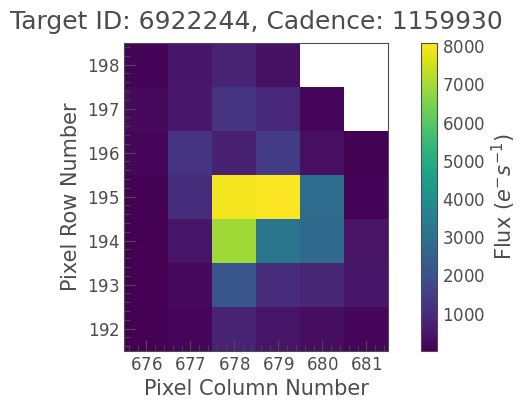

In [10]:
tpf = lk.search_targetpixelfile('Kepler-8', quarter=10).download()
tpf.plot();

* **Light Curve Files (LCFs)**: These are processed products created by the TESS or Kepler pipeline. The pipeline extracts flux from TPFs and removes many instrumental effects. Each LCF typically contains two light curves:
  - **SAP (Simple Aperture Photometry)**: Basic flux measurements with minimal processing
  - **PDCSAP (Pre-search Data Conditioning SAP)**: "Corrected" flux with instrumental systematics removed — this is usually what you want for science analysis
  - Used when: You want pre-processed, pipeline-corrected data (faster analysis, higher quality)

/Users/user1/Data/BRICS/brics_astro/.venv/lib/python3.10/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 5 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


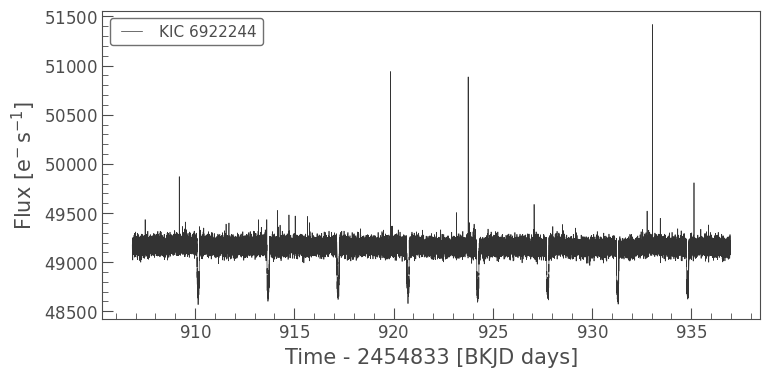

In [11]:
lcf = lk.search_lightcurve('Kepler-8', quarter=10).download()
lcf.plot();

* **Light Curves (LC)**: A light curve is just the brightness (flux) of a star plotted over time. Lightkurve can work with light curves from any source — not just TESS or Kepler. If you have time and flux measurements, lightkurve can help you analyze them.
  - Each LCF contains two light curves (SAP and PDCSAP)
  - You can also extract light curves from TPFs by summing flux within an aperture
  - Or create your own from any external data

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/1861168970.py:1: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcf.PDCSAP_FLUX


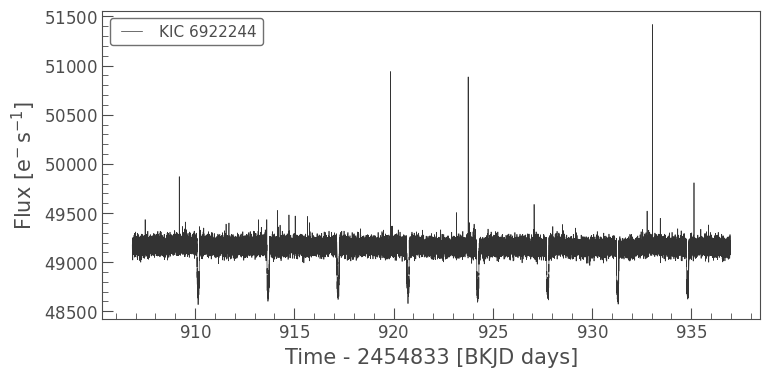

In [14]:
lc = lcf.PDCSAP_FLUX
lc.plot();

## 3. Lightkurve workflow

**Learning outcome:** Understand the typical workflow for working with space telescope light curve data.

The primary workflow for working with TESS and Kepler data follows these steps:

1. **Search and Download**: Use `lk.search_lightcurvefile()` or `lk.search_targetpixelfile()` to find data
2. **Extract or Load**: Get light curves from LCFs or extract them from TPFs
3. **Clean**: Remove bad data points, outliers, and cosmic rays
4. **Normalize**: Put flux values on a common scale (e.g., relative to mean flux)
5. **Detrend**: Remove long-term instrumental drifts while preserving real signals
6. **Analyze**: Search for periodic signals, transits, flares, or other features

We'll demonstrate this workflow using real data throughout this tutorial.

## 3.1 Working with a TPF

**Learning outcome:** Learn how to load, inspect, and extract light curves from raw pixel-level data.

Target Pixel Files contain 2D images of your target over time. The most interesting data in a `KeplerTargetPixelFile` object are:
- `flux`: The brightness values in each pixel over time
- `time`: The timestamps for each observation

Let's load a TPF and examine its time axis. You can access the timestamps using the `time` property:

In [15]:
tpf.time

<Time object: scale='tdb' format='bkjd' value=[906.83657298 906.8372542  906.83793531 ... 936.9539809  936.954662
 936.955343  ]>

By default, `time` is in the Kepler-specific *Barycentric Kepler Julian Day* format (BKJD). You can easily convert this into [AstroPy Time objects](http://docs.astropy.org/en/stable/time/) using the `astropy_time` property:

In [16]:
tpf.astropy_time

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/1028172023.py:1: LightkurveDeprecationWarning: The astropy_time function is deprecated and may be removed in a future version.
        Use time instead.
  tpf.astropy_time


<Time object: scale='tdb' format='bkjd' value=[906.83657298 906.8372542  906.83793531 ... 936.9539809  936.954662
 936.955343  ]>

Next, let's look at the actual image data, which is available via the `flux` property:

In [17]:
tpf.flux.shape

(43978, 7, 6)

The `flux` data is a 18104 x 21 x 11 array in units electrons/second. The first axis is the time axis, and the images themselves are 21 pixels by 11 pixels. You can use the `plot` method on the `KeplerTargetPixelFile` object to view the data.

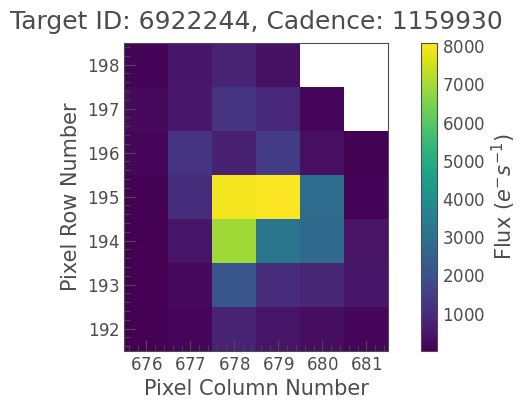

In [18]:
tpf.plot();

You also have acces to the pipeline generated pixel mask. This mask can be used to generate a light curve, or you can create your own.

In [19]:
tpf.pipeline_mask

array([[False, False, False, False, False, False],
       [False, False,  True,  True,  True, False],
       [False, False,  True,  True,  True, False],
       [False, False,  True,  True,  True, False],
       [False, False,  True,  True, False, False],
       [False, False,  True, False, False, False],
       [False, False, False, False, False, False]])

<Axes: title={'center': 'Target ID: 6922244, Cadence: 1159930'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

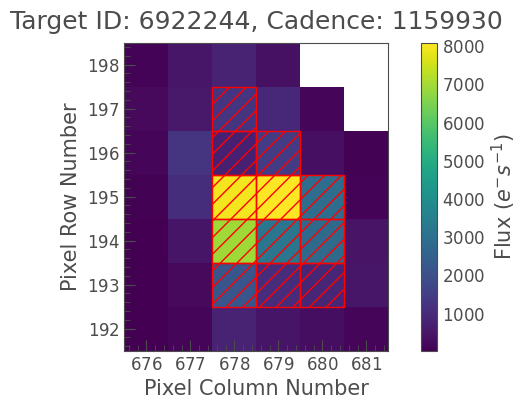

In [20]:
tpf.plot(aperture_mask=tpf.pipeline_mask)

The `create_threshold_mask` method will allow you to build your own aperture. You can choose a `sigma` level above the background, and light curve will automatically select a target above that threshold.

<Axes: title={'center': 'Target ID: 6922244, Cadence: 1159930'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

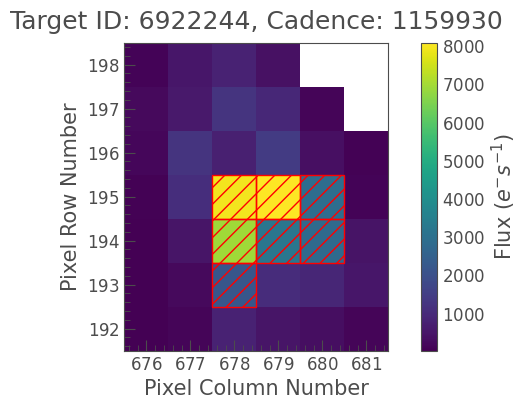

In [21]:
aper = tpf.create_threshold_mask(threshold=2)
tpf.plot(aperture_mask=aper)

Now that we have an aperture, we can sum up the flux inside the aperture and create a light curve.

In [22]:
lc = tpf.to_lightcurve(aperture_mask=aper)

## 3.2 Working with Light Curves

**Learning outcome:** Understand how to extract, manipulate, and visualize light curves using lightkurve's powerful object-oriented interface.

Once you've extracted or loaded a light curve, lightkurve provides a rich set of methods to analyze it. Light curve objects have properties like `time`, `flux`, `flux_err` and methods like `.plot()`, `.scatter()`, and `.errorbar()` for visualization.

In [23]:
lc

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float32,float32,float64,float64,int32,int32
906.8365729835714,36472.7734375,33.578922271728516,678.6888564136561,194.52636251168732,1159930,0
906.8372541970748,36505.05078125,33.58994674682617,678.6879278022636,194.5250124982705,1159931,0
906.8379353105847,36437.875,33.57048797607422,678.6890568021598,194.52537387452915,1159932,0
906.838616524321,36477.72265625,33.58009719848633,678.6893887879128,194.52624453366604,1159933,0
906.8392974378221,36458.12109375,33.57564926147461,678.6886153837253,194.52612296680513,1159934,0
906.8399786513255,36438.55859375,33.57261657714844,678.6896742775269,194.52598209250138,1159935,0
906.8406597648282,36455.42578125,33.57535171508789,678.6883595417628,194.5252623896756,1159936,0
906.8413409783388,36433.58203125,33.56779479980469,678.687630829891,194.52577927145254,1159937,0


`lc` is now a `TessLightCurve`, which has new properties and methods. For example, light curves also have a `plot` method:


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

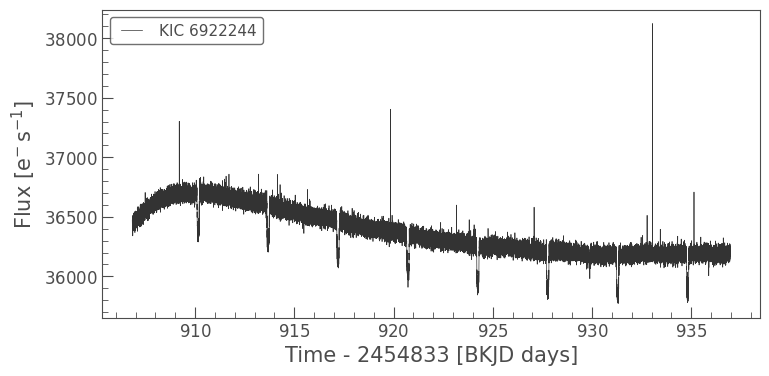

In [24]:
lc.plot()

You can interact with this object using familiar `matplotlib.pyplot` keywords and syntax. There are also `scatter` and `errorbar` plotting methods.

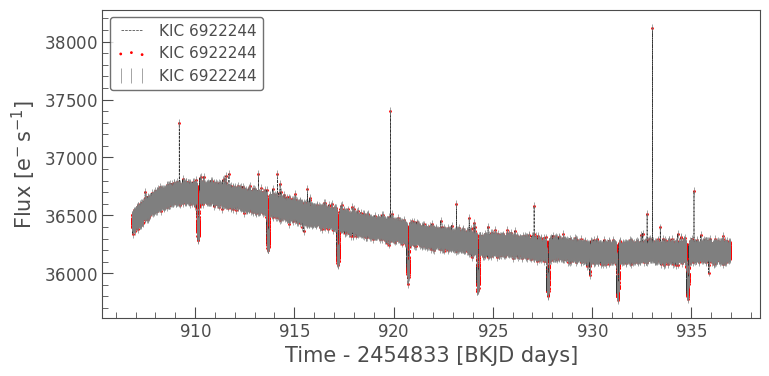

In [26]:
ax = lc.plot(ls='--')
lc.errorbar(ax=ax, c='grey')
lc.scatter(ax=ax, c='r');

You can also use the `interact` method to interactively view the pixel data

In [ ]:
tpf.interact('http://localhost:8987') # This will fail if running from google collab, but will work if you run locally!

**Remember:** You can access the pipeline corrected light curves using light curve files from MAST. These have been corrected for instrument systematics.

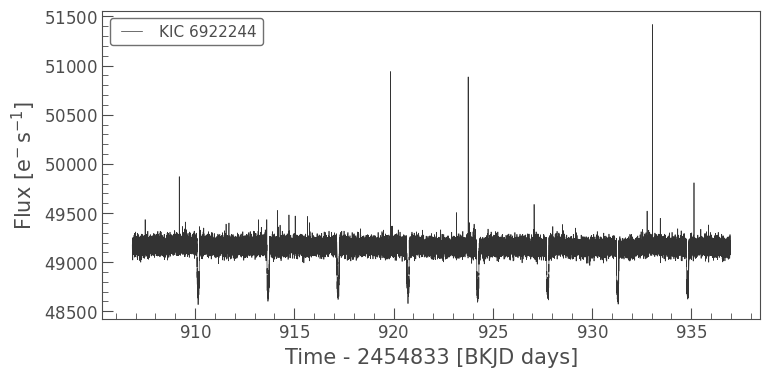

In [28]:
lcf.plot();

In [29]:
lcf.PDCSAP_FLUX

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/533704544.py:1: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lcf.PDCSAP_FLUX


time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
906.8365729835714,4.9176000e+04,4.6120747e+01,0,3.016344e-03,678.62921,194.71787,1159930,4.1844359e+04,3.8294254e+01,1.7567740e+03,7.1397835e-01,4.9176000e+04,4.6120747e+01,0,———,———,———,———,678.62921,1.1703738e-03,194.71787,1.5916293e-03,-2.6843483e-02,5.3613111e-02
906.8372541970748,4.9209125e+04,4.6123737e+01,0,3.016357e-03,678.63041,194.71646,1159931,4.1871582e+04,3.8303776e+01,1.7566193e+03,7.1396577e-01,4.9209125e+04,4.6123737e+01,0,———,———,———,———,678.63041,1.1693428e-03,194.71646,1.5903658e-03,-2.6837232e-02,5.3616919e-02
906.8379353105847,4.9152520e+04,4.6101433e+01,0,3.016371e-03,678.63058,194.71717,1159932,4.1822941e+04,3.8290989e+01,1.7564647e+03,7.1395332e-01,4.9152520e+04,4.6101433e+01,0,———,———,———,———,678.63058,1.1712613e-03,194.71717,1.5934192e-03,-2.6830982e-02,5.3620722e-02
906.838616524321,4.9191273e+04,4.6101135e+01,0,3.016384e-03,678.63205,194.71864,1159933,4.1855008e+04,3.8296871e+01,1.7563099e+03,7.1394080e-01,4.9191273e+04,4.6101135e+01,0,———,———,———,———,678.63205,1.1691204e-03,194.71864,1.5903555e-03,-2.6824731e-02,5.3624529e-02
906.8392974378221,4.9185078e+04,4.6094749e+01,0,3.016398e-03,678.62809,194.71726,1159934,4.1849086e+04,3.8297108e+01,1.7561554e+03,7.1392834e-01,4.9185078e+04,4.6094749e+01,0,———,———,———,———,678.62809,1.1700445e-03,194.71726,1.5915738e-03,-2.6818484e-02,5.3628337e-02
906.8399786513255,4.9126031e+04,4.6077744e+01,0,3.016411e-03,678.63033,194.71878,1159935,4.1798500e+04,3.8287804e+01,1.7560007e+03,7.1391582e-01,4.9126031e+04,4.6077744e+01,0,———,———,———,———,678.63033,1.1712190e-03,194.71878,1.5932659e-03,-2.6812233e-02,5.3632144e-02
906.8406597648282,4.9145371e+04,4.6072975e+01,0,3.016425e-03,678.63044,194.71797,1159936,4.1814258e+04,3.8288746e+01,1.7558461e+03,7.1390337e-01,4.9145371e+04,4.6072975e+01,0,———,———,———,———,678.63044,1.1714684e-03,194.71797,1.5938432e-03,-2.6805984e-02,5.3635951e-02
906.8413409783388,4.9161730e+04,4.6068920e+01,0,3.016438e-03,678.63053,194.71996,1159937,4.1827527e+04,3.8289974e+01,1.7556915e+03,7.1389079e-01,4.9161730e+04,4.6068920e+01,0,———,———,———,———,678.63053,1.1708266e-03,194.71996,1.5925393e-03,-2.6799733e-02,5.3639758e-02


## 8. Troubleshooting and Contributing

**Resources for help and getting involved:**

If you encounter issues using lightkurve:

1. **Check the documentation**: http://docs.lightkurve.org/ — comprehensive tutorials and API reference
2. **Search GitHub Issues**: https://github.com/KeplerGO/lightkurve/issues — many common problems have solutions
3. **Post an Issue**: If you find a bug or have a feature request, open an issue on GitHub with a minimal example
4. **Contribute Code**: Lightkurve is open-source and welcomes contributions. See CONTRIBUTING.md in the repository.

Remember: When reporting issues, include:
- Your lightkurve version (check with `lk.__version__`)
- Your Python version
- A minimal code example that reproduces the problem
- Full error traceback

Light curves can be corrected with the following methods:

 * `lc.remove_nans()`
 * `lc.remove_outliers()`
 * `lc.normalize()`
 * `lc.flatten()`
 * `lc.bin()`

**Remember:** You can read more about each method in the docs, or in our docstrings.

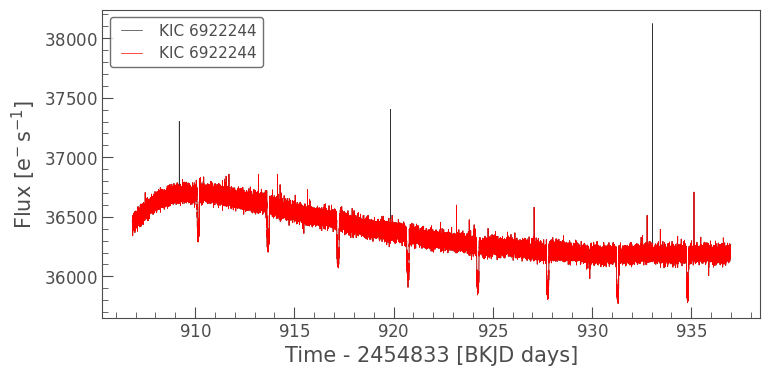

In [30]:
ax = lc.plot()
lc.remove_outliers(sigma=5).plot(ax=ax, c='red');

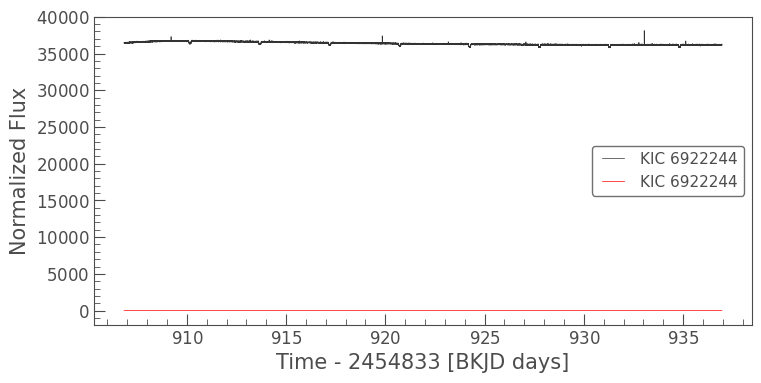

In [31]:
ax = lc.plot()
lc.flatten(window_length=1501, break_tolerance=50).plot(ax=ax, c='red');

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/2838730391.py:2: LightkurveDeprecationWarning: "binsize" was deprecated in version 2.0 and will be removed in a future version. 
        Use time_bin_size instead.
  lc.bin(binsize=100).plot(ax=ax, c='red');


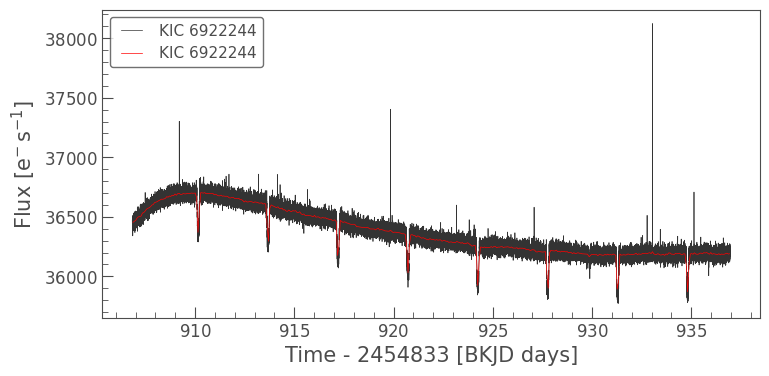

In [32]:
ax = lc.plot()
lc.bin(binsize=100).plot(ax=ax, c='red');

## 4.1 Folding Light Curves

**Learning outcome:** Learn how to reveal periodic signals by folding light curves at their known periods.

When looking for periodic signals, it's useful to "fold" a light curve at a period and align all observations to a reference point (usually the first occurrence of the signal). Folding stacks many orbits on top of each other, which makes weak signals much more visible. The lightkurve `fold()` method makes this simple.

When looking for periodic signals, it's useful to be able to fold a light curve at a period and midpoint. Light curve lets you do this with the `fold` method on light curves.

In [33]:
period = 3.5224991
t0 = 2454954.11931 - 2454833 # Convert to BKJD

For now, let's take the the PDCSAP_FLUX from the Kepler Pipeline version of the data, as this has had most of the Kepler systematics removed for us.

In [34]:
lc = lcf.PDCSAP_FLUX
folded_lc = lc.fold(period, t0)
folded_lc

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/986914016.py:1: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcf.PDCSAP_FLUX


time,flux,flux_err,time_original,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
TimeDelta,float32,float32,Time,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
-1.7612290631308012,4.9060441e+04,4.5324326e+01,926.0103748368492,0,3.285997e-03,678.66115,194.65410,1188080,4.1416164e+04,3.8109066e+01,1.7197622e+03,7.1169955e-01,4.9060441e+04,4.5324326e+01,0,———,———,———,———,678.66115,1.1763086e-03,194.65410,1.6037271e-03,8.4385416e-03,-1.5981594e-02
-1.7611288696210263,4.9120859e+04,4.5747169e+01,918.965476830359,0,3.213490e-03,678.64679,194.68348,1177737,4.1670684e+04,3.8183834e+01,1.7294890e+03,7.1116120e-01,4.9120859e+04,4.5747169e+01,0,———,———,———,———,678.64679,1.1719272e-03,194.68348,1.5971307e-03,-6.1143786e-03,1.2495369e-02
-1.7610990638085369,4.9185754e+04,4.5527012e+01,936.5780021361716,0,3.334296e-03,678.67756,194.62024,1203595,4.1492801e+04,3.8164337e+01,1.7077716e+03,7.1014613e-01,4.9185754e+04,4.5527012e+01,0,———,———,———,———,678.67756,1.1740669e-03,194.62024,1.6020299e-03,2.8053097e-02,-5.3064007e-02
-1.7610601504996628,4.9182758e+04,4.6335712e+01,911.9205473494803,0,3.109809e-03,678.63486,194.70892,1167394,4.2070020e+04,3.8339169e+01,1.7458148e+03,7.1278173e-01,4.9182758e+04,4.6335712e+01,0,———,———,———,———,678.63486,1.1672783e-03,194.70892,1.5889117e-03,-2.0206252e-02,4.1201320e-02
-1.7609504133523741,4.9226844e+04,4.5775826e+01,929.5331525866277,0,3.310247e-03,678.66787,194.64120,1193252,4.1515723e+04,3.8127113e+01,1.7109305e+03,7.1245372e-01,4.9226844e+04,4.5775826e+01,0,———,———,———,———,678.66787,1.1746521e-03,194.64120,1.6012379e-03,1.4859764e-02,-2.9213287e-02
-1.7608344474291369,4.9014863e+04,4.5590176e+01,922.4882703525509,0,3.253713e-03,678.65314,194.67055,1182909,4.1472727e+04,3.8124447e+01,1.7186576e+03,7.1179682e-01,4.9014863e+04,4.5590176e+01,0,———,———,———,———,678.65314,1.1755635e-03,194.67055,1.6024951e-03,1.1419668e-03,-2.1176215e-03
-1.7607500823285942,4.9098508e+04,4.5579803e+01,915.4433565176514,0,3.165478e-03,678.64091,194.69492,1172566,4.1821527e+04,3.8221222e+01,1.7331898e+03,7.1071106e-01,4.9098508e+04,4.5579803e+01,0,———,———,———,———,678.64091,1.1710102e-03,194.69492,1.5942655e-03,-1.3627082e-02,2.7049325e-02
-1.7606965834628217,4.9119859e+04,4.6751728e+01,908.3984118165172,0,3.046677e-03,678.62889,194.71856,1162223,4.2013871e+04,3.8339470e+01,1.7483394e+03,7.1300286e-01,4.9119859e+04,4.6751728e+01,0,———,———,———,———,678.62889,1.1692528e-03,194.71856,1.5911072e-03,-2.5925402e-02,5.1973779e-02


`FoldedLightCurve` is a class similar to `LightCurve`, but it has the `phase` attribute.

In [35]:
folded_lc.phase

<TimeDelta object: scale='None' format='jd' value=[-1.76122906 -1.76112887 -1.76109906 ...  1.76106781  1.7611214
  1.76113791]>

This time has been folded at the period given, and centered around t0. Plotting a folded light curve will show a plot in phase.

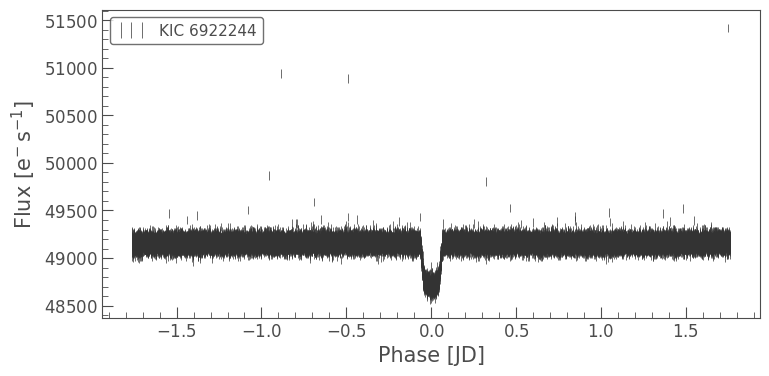

In [36]:
folded_lc.errorbar();

We see here there is a transit in the center!

## 4.2 Stringing Commands Together

**Learning outcome:** Write clean, readable, and efficient data processing pipelines using method chaining.

One of lightkurve's best features is the ability to chain multiple operations together into a single, readable "sentence." Instead of creating intermediate variables for each step, you can apply transformations sequentially. This makes your code more readable and Pythonic.

Using light curve it is possible to string these commands together in a single "sentence".

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/2860271442.py:1: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcf.PDCSAP_FLUX.remove_nans().flatten(window_length=501, break_tolerance=50).remove_outliers(sigma_upper=4, sigma_lower=10)


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

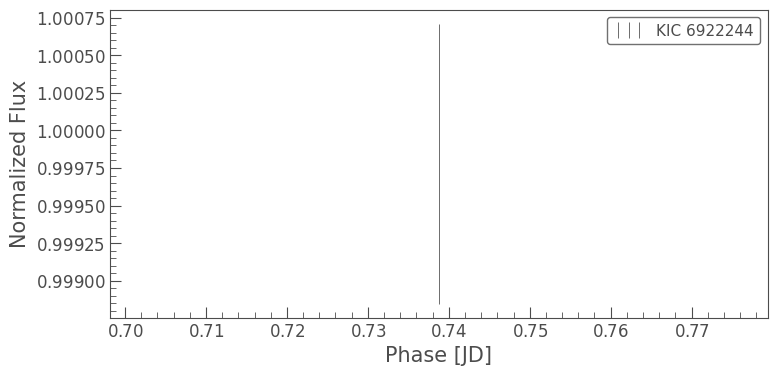

In [37]:
lc = lcf.PDCSAP_FLUX.remove_nans().flatten(window_length=501, break_tolerance=50).remove_outliers(sigma_upper=4, sigma_lower=10)
lc.fold(period, t0).bin(5).errorbar()

## 5. Converting light curves to other formats

**Learning outcome:** Export your processed light curves for collaboration and archival purposes.

When you have created and analyzed a light curve, you often need to share it with collaborators or submit it to data archives like MAST. Lightkurve provides simple methods to convert light curves into standard formats that other tools can read.

When you have created a light curve you may want to share it with collaborators, or submit your light curves as High Level Science Products to the MAST archive. Lightkurve lets you do this by converting light curves to files. The following methods allow easy file sharing:

* `lc.to_pandas()`
* `lc.to_fits(PATH)`
* `lc.to_csv(PATH)`

In [38]:
lc.to_pandas().head(5)

,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,...,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
time,,,,,,,,,,,,,,,,,,,,,
906.836573,1.000189,0.000938,0,0.003016,678.629207,194.717867,1159930,41844.359375,38.294254,1756.774048,...,NaN,NaN,NaN,NaN,678.629207,0.001170,194.717867,0.001592,-0.026843,0.053613
906.837254,1.000863,0.000938,0,0.003016,678.630406,194.716464,1159931,41871.582031,38.303776,1756.619263,...,NaN,NaN,NaN,NaN,678.630406,0.001169,194.716464,0.001590,-0.026837,0.053617
906.837935,0.999712,0.000938,0,0.003016,678.630579,194.717171,1159932,41822.941406,38.290989,1756.464722,...,NaN,NaN,NaN,NaN,678.630579,0.001171,194.717171,0.001593,-0.026831,0.053621
906.838617,1.000500,0.000938,0,0.003016,678.632050,194.718643,1159933,41855.007812,38.296871,1756.309937,...,NaN,NaN,NaN,NaN,678.632050,0.001169,194.718643,0.001590,-0.026825,0.053625
906.839297,1.000374,0.000938,0,0.003016,678.628087,194.717259,1159934,41849.085938,38.297108,1756.155396,...,NaN,NaN,NaN,NaN,678.628087,0.001170,194.717259,0.001592,-0.026818,0.053628


In [ ]:
lc.to_fits('output.fits', overwrite=True)

In [ ]:
% ls -lh output.fits

-rw-r--r--  1 ch  staff   129K Mar  6 10:06 output.fits


## 6. Searching for Targets

**Learning outcome:** Master the lightkurve search interface to locate and download data for any star observed by TESS, Kepler, or K2.

Finding data on MAST (the Mikulski Archive for Space Telescopes) is the first step in any lightkurve analysis. Lightkurve provides powerful search functions that let you find data by name, coordinates, ID numbers, or even spatial proximity. Let's explore these search capabilities.

Now we know how to work with the data, let's revisit how you can find data on MAST using light curve. We have two main search functions

* `search_targetpixelfile`
* `search_lightcurvefile`

These will allow you to find targets on MAST using either

* KIC/EPIC/TIC ID
* RA/Dec
* astropy.SkyCoord object
* Target name

In [40]:
search_result = lk.search_lightcurve('Kepler-10')

In [41]:
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr011904151,0.0
1,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
2,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
4,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 04,2010,Kepler,60,kplr011904151,0.0


This has returned a `SearchResult` object, which has a list of all the products available on MAST. Here we see there are several long cadence light curves available, one for each quarter. You can cut down this list by specifying keywords.

In [43]:
search_result = lk.search_lightcurve('Kepler-10', quarter=3)

In [44]:
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
1,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
2,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
4,Kepler Quarter,2009,KBONUS-BKG,1765,Gaia DR3 2132155017099178624,0.0


Alternately, you can index into the search result

In [45]:
search_result = lk.search_lightcurve('Kepler-10')
search_result[3]

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0


Once you have a search result and you would like to download it, simply add the `download()` method.

In [46]:
lcf = search_result[3].download()

In [47]:
lcf

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
260.21433480949054,———,———,0,2.001269e-03,655.16335,246.38035,210580,5.1419497e+05,1.0699422e+02,2.3402817e+03,1.2032824e+00,———,———,0,———,———,———,———,655.16335,2.3171435e-04,246.38035,2.9024007e-04,-5.9430343e-03,2.6158990e-02
260.2150158936565,5.2455894e+05,1.1148436e+02,0,2.001254e-03,655.16431,246.38079,210581,5.1398469e+05,1.0697855e+02,2.3402622e+03,1.2033111e+00,5.2455894e+05,1.1148436e+02,0,———,———,———,———,655.16431,2.3176182e-04,246.38079,2.9038105e-04,-5.9309248e-03,2.6156019e-02
260.2156970778233,5.2474856e+05,1.1143040e+02,0,2.001238e-03,655.16425,246.38061,210582,5.1416031e+05,1.0699407e+02,2.3402424e+03,1.2033398e+00,5.2474856e+05,1.1143040e+02,0,———,———,———,———,655.16425,2.3178069e-04,246.38061,2.9032509e-04,-5.9188139e-03,2.6153047e-02
260.21637816198927,5.2494000e+05,1.1138225e+02,0,2.001222e-03,655.16379,246.38024,210583,5.1433822e+05,1.0701044e+02,2.3402227e+03,1.2033685e+00,5.2494000e+05,1.1138225e+02,0,———,———,———,———,655.16379,2.3163165e-04,246.38024,2.9029741e-04,-5.9067043e-03,2.6150076e-02
260.21705924615526,5.2487731e+05,1.1131572e+02,0,2.001206e-03,655.16505,246.38105,210584,5.1426934e+05,1.0700402e+02,2.3402031e+03,1.2033972e+00,5.2487731e+05,1.1131572e+02,0,———,———,———,———,655.16505,2.3168736e-04,246.38105,2.9022113e-04,-5.8945948e-03,2.6147105e-02
260.21774023032776,5.2477888e+05,1.1125045e+02,0,2.001190e-03,655.16427,246.38093,210585,5.1416603e+05,1.0699453e+02,2.3401833e+03,1.2034259e+00,5.2477888e+05,1.1125045e+02,0,———,———,———,———,655.16427,2.3172391e-04,246.38093,2.9022433e-04,-5.8824872e-03,2.6144134e-02
260.2184214144945,5.2481594e+05,1.1120132e+02,0,2.001174e-03,655.16359,246.38123,210586,5.1419509e+05,1.0699690e+02,2.3401638e+03,1.2034546e+00,5.2481594e+05,1.1120132e+02,0,———,———,———,———,655.16359,2.3176424e-04,246.38123,2.9036342e-04,-5.8703762e-03,2.6141161e-02
260.2191024986605,5.2476106e+05,1.1114898e+02,0,2.001159e-03,655.16477,246.38066,210587,5.1413506e+05,1.0699224e+02,2.3401440e+03,1.2034832e+00,5.2476106e+05,1.1114898e+02,0,———,———,———,———,655.16477,2.3178171e-04,246.38066,2.9024595e-04,-5.8582667e-03,2.6138190e-02


This has now returned a Light Curve File, which we can use in the same way as above. Below are some examples of how to search for data

In [50]:
lcf = lk.search_lightcurve('026.0170142608, -15.9374795978').download_all()

In [51]:
from astropy.coordinates import SkyCoord
import astropy.units as u
c = SkyCoord(026.0170142608, -15.9374795978, unit=(u.deg, u.deg))
lcf = lk.search_lightcurve(c).download_all()

In [52]:
tpf = lk.search_targetpixelfile('KIC 8462852', quarter=10).download()

You can also use the `download_all` method, to download the full manifest of a search. This will return a `LightCurveFileCollection` object, which is a group of light curves.

### 6.1 Radius Queries

**What to learn:** Find multiple targets near a star of interest — useful for studying systematics or blended light sources.

The `radius` parameter in search functions allows you to find not just your target, but all objects within a specified radius. This is valuable for:
- Checking if nearby stars contaminate your target's light
- Finding reference stars for differential photometry
- Studying stellar populations in crowded fields

Using the `search_...` functions, it is possible to do a radius query, and find targets that are nearby to your target of interest. This is particularly useful when trying to assess systematics in your target.

In [ ]:
# Find the nearest three targets within 100 arcseconds
search_result = lk.search_lightcurvefile('Kepler-10', quarter=3, radius=100, limit=3)

### 6.2 Obtaining TESS FFI Cut-outs

**What to learn:** Access TESS Full-Frame Image (FFI) data for targets not in the main mission or for extended sources.

TESS observes the entire sky, and those observations are archived as Full-Frame Images (FFIs). You can query the TESS FFI archive to get small "cutouts" centered on your target. Note: FFI cutouts are not pipeline products, so they require more careful processing than official light curves.

New in lightkurve you can now search for TESS cut outs in the FFIs. This feature uses the TESSCut tool from MAST.

In [56]:
lk.search_tesscut('026.0170142608, -15.9374795978')

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 03,2018,TESScut,1426,"026.0170142608, -15.9374795978",0.0
1,TESS Sector 30,2020,TESScut,475,"026.0170142608, -15.9374795978",0.0
2,TESS Sector 97,2025,TESScut,158,"026.0170142608, -15.9374795978",0.0


In [57]:
tpf = lk.search_tesscut('Pi Men').download(cutout_size=20);

/Users/user1/Data/BRICS/brics_astro/.venv/lib/python3.10/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 25 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


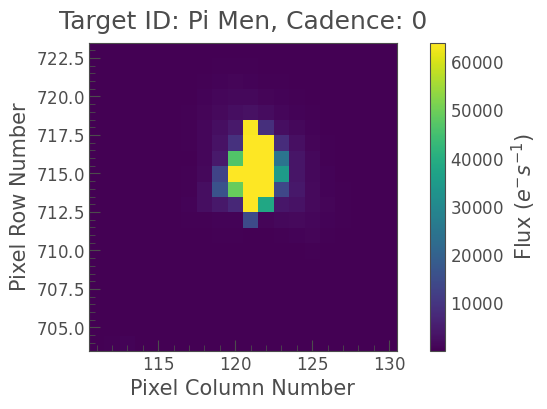

In [58]:
tpf.plot();

**Remember**: These are not Pipeline products, these are simply cut outs of the TESS FFIs. Because of this, they do not have aperture masks. You will have to create your own! The FFIs also do not have background removed, and have many instrument systematics. Make sure you correct for these!

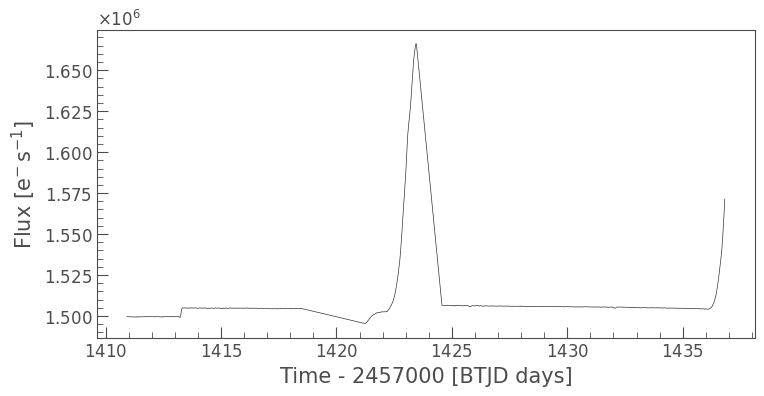

In [59]:
aper = tpf.create_threshold_mask()
tpf.to_lightcurve(aperture_mask=aper).plot();

### 6.3 Stitching Light Curves

**What to learn:** Combine light curves from multiple observing quarters or sectors into a single continuous dataset.

Kepler observed for several years, but the spacecraft rotated every quarter (~90 days), producing separate light curve files for each quarter. TESS similarly observes in sectors. To get the full picture, you often need to "stitch together" (append) multiple light curves into one continuous time series. Lightkurve makes this seamless.

You can use lightkurve for Kepler data too! There are one or two helpful classes for dealing with Kepler data that are worth mentioning.

Kepler data was split into many 'quarters', each of which must be stitched together. The Continuous Viewing Zone in TESS will also have targets that will be revisited, and so some TESS targets will also require stitched together.

To do this we first use the `download_all` method on our search.

In [ ]:
lcfs = lk.search_lightcurvefile('KIC 12216817').download_all()

In [ ]:
lcfs

LightCurveFileCollection of 18 objects:
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 
KeplerLightCurveFile(ID: 12216817) 

In [ ]:
# Use the normalized PDCSAP_FLUX
lc = lcfs[0].PDCSAP_FLUX.normalize()

# Loop through the rest of the LCFS, appending to the first light curve
for lcf in lcfs[1:]:
    lc = lc.append(lcf.PDCSAP_FLUX.normalize())

In [ ]:
lc

KeplerLightCurve(ID: 12216817)

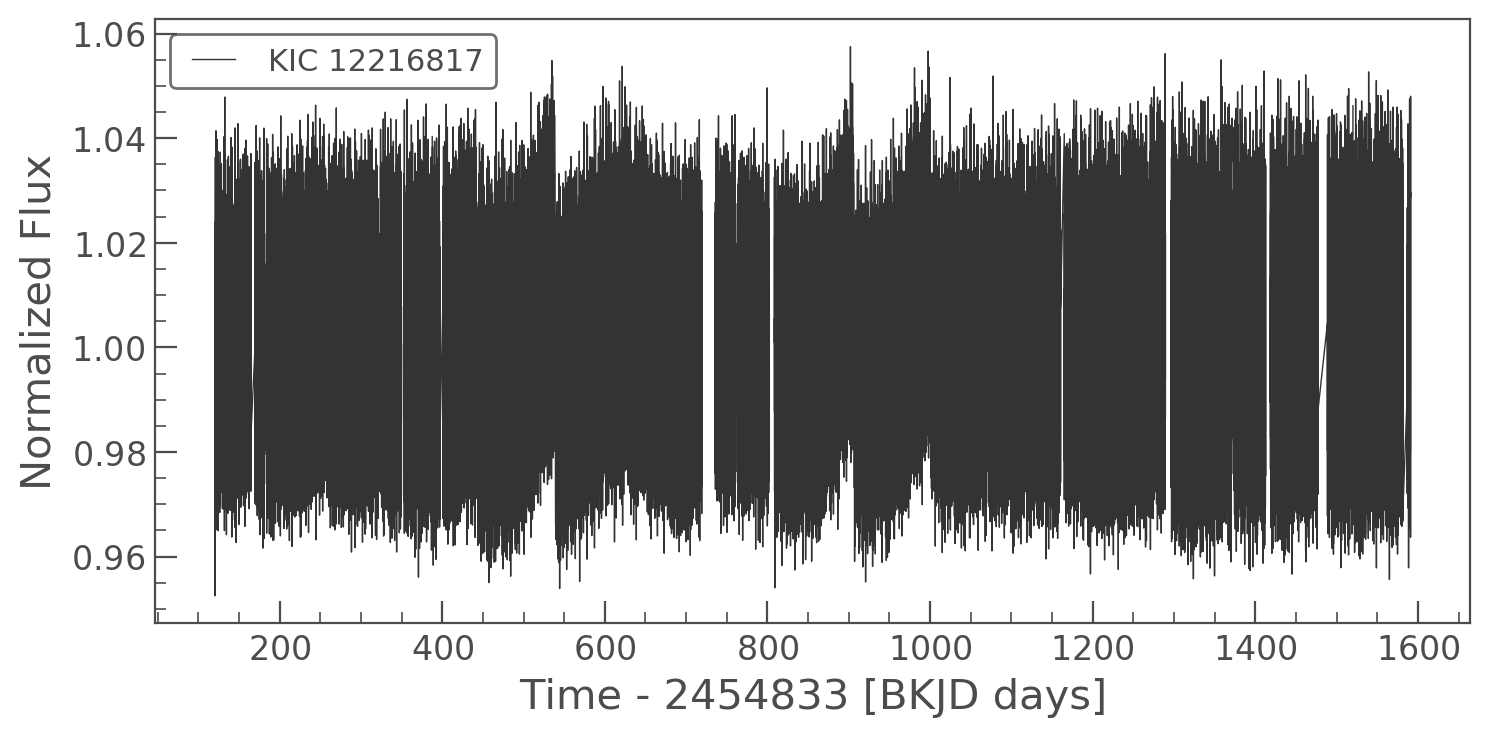

In [ ]:
lc.plot()

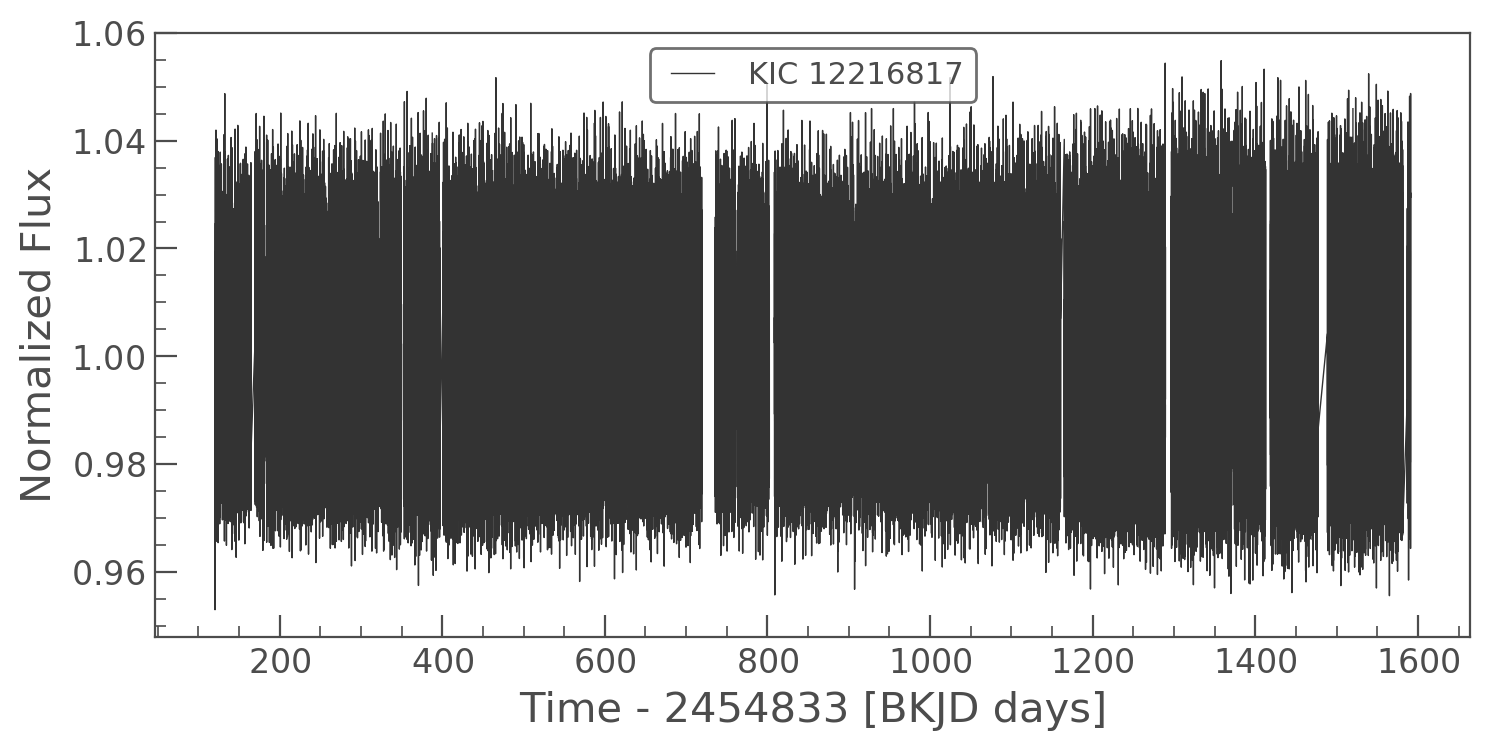

In [ ]:
lc = lc.flatten(window_length=701, break_tolerance=50)
lc.plot()

## 7. Periodograms

**Learning outcome:** Discover periodic signals in light curves using Fourier analysis and specialized transit-detection algorithms.

The holy grail of time-domain astronomy is finding periodic signals — whether it's an exoplanet orbit, stellar pulsations, or stellar rotation. A periodogram is a tool that shows which frequencies (or periods) contain the most power in your light curve. Lightkurve supports multiple periodogram types for different science cases.

We often care about periodic signals when we're using Kepler and TESS data. Lightkurve has a handy built in `Periodogram` class which can help you search for periodic signals.

In [ ]:
import numpy as np
# Create periodogram object
p = lc.remove_nans().to_periodogram(method='LombScargle')

In [ ]:
p

LombScarglePeriodogram(ID: 12216817)

This has now created a `Periodogram` class object, which has many useful methods and attributes. You will mostly be using the `plot` method:

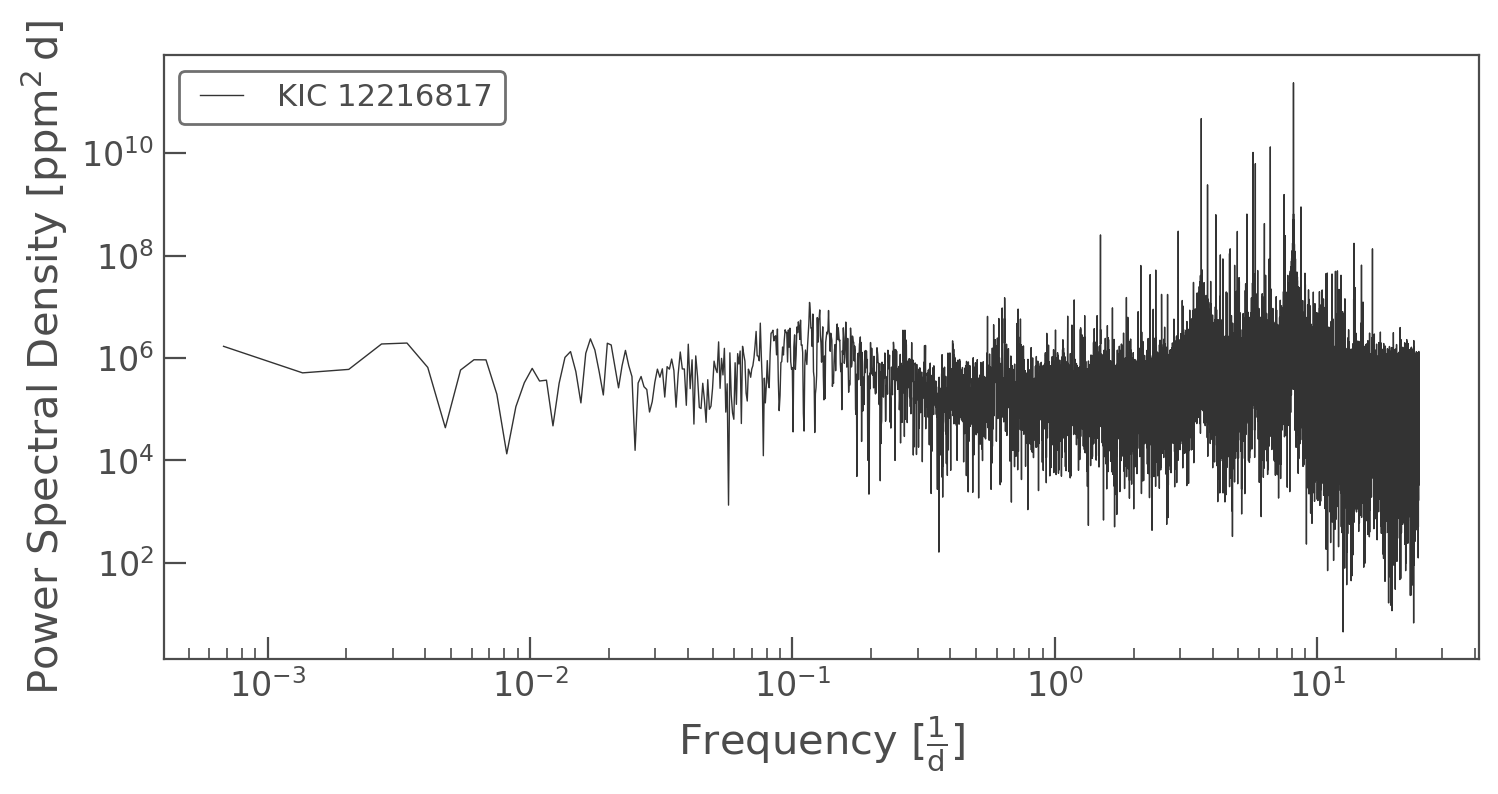

In [ ]:
p.plot(scale='log')

There is a strong periodicity in this data! The `Periodogram` object has an attribute `period_at_max_power` which stores the best period.

In [ ]:
p.period_at_max_power

<Quantity 0.12313369 d>

If we fold the light curve at this period, we find a strong periodic signal!

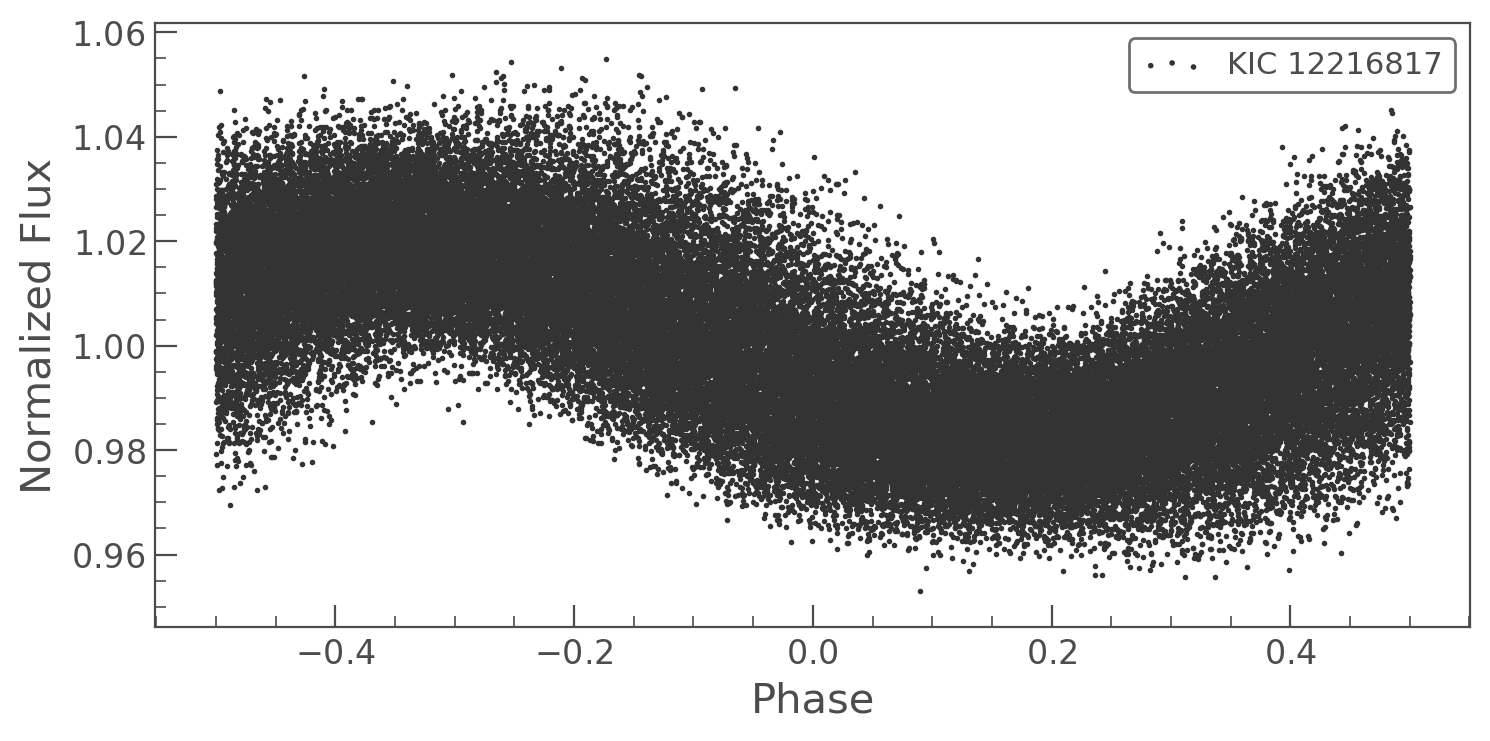

In [ ]:
lc.fold(p.period_at_max_power.value).scatter();

### 7.1 BLS Periodograms

**What to learn:** Use the Box Least Squares algorithm to find shallow transit signals in noisy light curves.

Above we used Lomb-Scargle periodograms, which are great for sinusoidal signals like stellar oscillations. But exoplanet transits are not sinusoidal — they produce brief, shallow dips in brightness. The **Box Least Squares (BLS)** algorithm is specifically designed to find these transit-like features. BLS looks for periodic "boxes" (constant-depth features) in the data, making it the algorithm of choice for planet hunters.

In this section, we'll use Kepler-8, a system with a dramatic 1% transit depth, to demonstrate BLS in action.

Above we have created a Lomb Scargle periodogram, which is useful for analyzing signals that are sinusoidal. It is also possible to create a BLS periodogram, which is useful for finding transits.

**Note:** There is a full tutorial on how BLS works and how to use it available in this directory!

In [60]:
lc = lk.search_lightcurvefile('Kepler-8', quarter=4).download()

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/3652987760.py:1: LightkurveDeprecationWarning: The search_lightcurvefile function is deprecated and may be removed in a future version.
        Use search_lightcurve() instead.
  lc = lk.search_lightcurvefile('Kepler-8', quarter=4).download()
/Users/user1/Data/BRICS/brics_astro/.venv/lib/python3.10/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 5 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


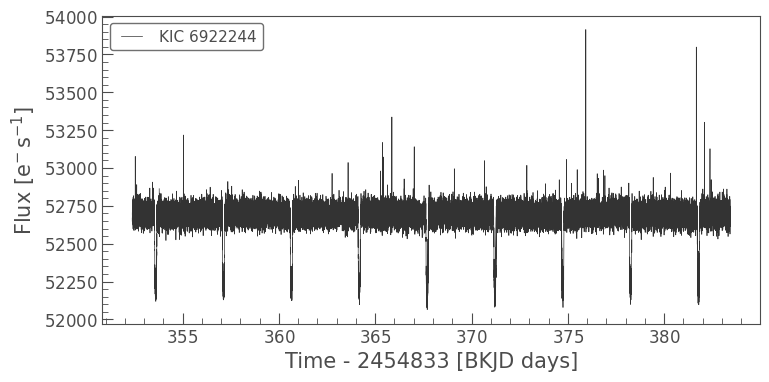

In [61]:
lc.plot();

In [62]:
# Note that we set the duration when we create the periodogram
p = lc.to_periodogram('bls', duration=0.1)
p

BoxLeastSquaresPeriodogram(ID: KIC 6922244)

`p` is now a `BoxLeastSquaresPeriodogram`, which still has the plot method

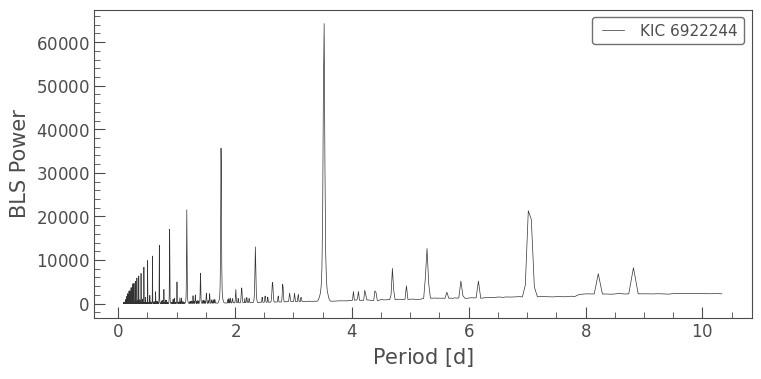

In [63]:
p.plot();

This time we have a few more attributes
* `p.period_at_max_power`
* `p.transit_time_at_max_power`
* `p.duration_at_max_power`
* `p.depth_at_max_power`

In [64]:
period = p.period_at_max_power.value
t0 = p.transit_time_at_max_power

We can now use these values to fold our light curve at the period of the planet.

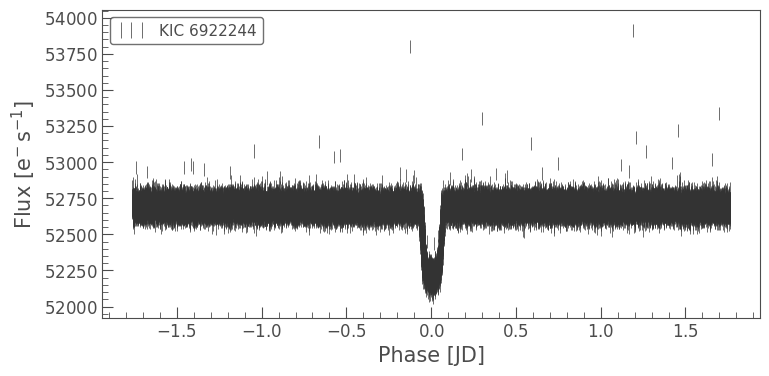

In [66]:
lc.fold(period, t0).errorbar();

Kepler-8 is a very deep planet transit (1%!) and so it is very easy to find with BLS. For shallower transits, it is worth iterating over a few of your detrending assumptions in order to find the strongest signal.

### 7.2 Interactively searching with BLS

**What to learn:** Use lightkurve's interactive widgets to explore periodogram peaks and fine-tune transit parameters.

Lightkurve provides an interactive BLS search tool via the `.interact_bls()` method. This launches a widget where you can adjust BLS parameters (duration, search period range) and see real-time results. It's excellent for:
- Exploring "false positives" and understanding which peaks are real signals
- Fine-tuning parameters based on what you see in the data
- Teaching others about BLS and transit detection

Lightkurve now has the new `interact_bls` method, which will let perform a BLS search with an interactive widget. This is useful for exploring the data and looking for transiting planets on a case by case basis.

In [ ]:
lc.normalize().interact_bls('http://localhost:8987') # This will fail if running from google collab, but will work if you run locally!

### 8. Troubleshooting and Contributing

Lightkurve is available on [github](github.com/keplerGO/lightkurve). If you have problems when using lightkurve, or think you've found a bug, please go ahead and submit an issue to our github describing the problem. We will try to get back to you quickly and fix your issue! If you would like to contribute a new feature to lightkurve and join our author list, please open a pull request with your new feature and we'll work with you to get it merged into lightkurve.

Congratulations on finishing the tutorial! We also have a full set of tutorials online at our [docs](http://docs.lightkurve.org/) which will go into more detail on all of our features. If you are stuck at any point, check out our full tutorials online.

## 9. Flare Analysis

**Learning outcome:** Detect and characterize stellar flares in high-cadence light curves, calculate flare rates, and measure flare energies.

Stellar flares are sudden, intense outbursts of energy released from magnetic reconnection in stellar atmospheres. They're particularly common on active M-dwarf stars like AU Microscopii (AU Mic). In this section, we'll use AU Mic observations from TESS to demonstrate how to detect flares, measure their properties, and calculate flare statistics.

**Why study flares?**
- Understanding stellar activity in exoplanet host stars (relevant for habitability)
- Characterizing stellar magnetic activity cycles
- Detecting and mitigating flare contamination in exoplanet transit searches
- Studying the high-energy environment around young stars

### 9.1 Introduction to Stellar Flares

**What to learn:** Understand what stellar flares are, why they're important, and what they look like in light curve data.

A stellar flare is a sudden, violent release of magnetic energy in a star's atmosphere. On our Sun, solar flares are well-documented and can affect Earth's magnetosphere. On other stars, especially young or active M dwarfs, flares can be dramatically larger and more frequent.

**Key properties of flares:**
- **Rise time**: Rapid increase in brightness (seconds to minutes)
- **Decay time**: Slower decline back to baseline (minutes to hours)
- **Peak brightness**: Can reach 50% or more above baseline for active stars
- **Frequency**: Active M dwarfs can have multiple flares per day

Let's load AU Microscopii (TIC 198900877), one of the closest and most active M dwarfs. This star is an excellent target for flare studies.

In [67]:
# Search for and download AU Microscopii light curve data
# AU Mic is a nearby (10 pc) M dwarf with frequent flares
au_mic_search = lk.search_lightcurvefile('AU Mic', mission='TESS', sector=1)
print("Available AU Mic data:")
print(au_mic_search)

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/2714838922.py:3: LightkurveDeprecationWarning: The search_lightcurvefile function is deprecated and may be removed in a future version.
        Use search_lightcurve() instead.
  au_mic_search = lk.search_lightcurvefile('AU Mic', mission='TESS', sector=1)


Available AU Mic data:
SearchResult containing 8 data products.

 #     mission     year       author      exptime target_name distance
                                             s                 arcsec 
--- -------------- ---- ----------------- ------- ----------- --------
  0 TESS Sector 01 2018              SPOC     120   441420236      0.0
  1 TESS Sector 01 2018         TESS-SPOC    1800   441420236      0.0
  2 TESS Sector 01 2018               QLP    1800   441420236      0.0
  3 TESS Sector 01 2018 GSFC-ELEANOR-LITE    1800   441420236      0.0
  4 TESS Sector 01 2018              TARS    1800   441420236      0.0
  5 TESS Sector 01 2018             TASOC     120   441420236      0.0
  6 TESS Sector 01 2018             TASOC    1800   441420236      0.0
  7 TESS Sector 01 2018             TASOC    1800   441420236      0.0


In [69]:
# Download the first sector and extract the PDCSAP flux
# (pipeline-corrected data with instrumental effects removed)
au_mic_lcf = au_mic_search[0].download()

# Modern approach: access flux from the light curve file
# Using the newer method to avoid deprecation warnings
au_mic_lc = au_mic_lcf.PDCSAP_FLUX if hasattr(au_mic_lcf, 'PDCSAP_FLUX') else au_mic_lcf

print(f"Light curve properties:")
print(f"  Mission: {au_mic_lc.mission}")
print(f"  Sector: {au_mic_lc.sector}")
# Convert time to numeric values (days) to avoid TimeDelta formatting issues
duration_days = (au_mic_lc.time.jd[-1] - au_mic_lc.time.jd[0])
cadence_minutes = (au_mic_lc.time.jd[1] - au_mic_lc.time.jd[0]) * 24 * 60
print(f"  Duration: {duration_days:.1f} days")
print(f"  Number of observations: {len(au_mic_lc)}")
print(f"  Cadence: {cadence_minutes:.1f} minutes")

Light curve properties:
  Mission: TESS
  Sector: 1
  Duration: 27.3 days
  Number of observations: 17802
  Cadence: 2.0 minutes


/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/3152860276.py:7: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  au_mic_lc = au_mic_lcf.PDCSAP_FLUX if hasattr(au_mic_lcf, 'PDCSAP_FLUX') else au_mic_lcf


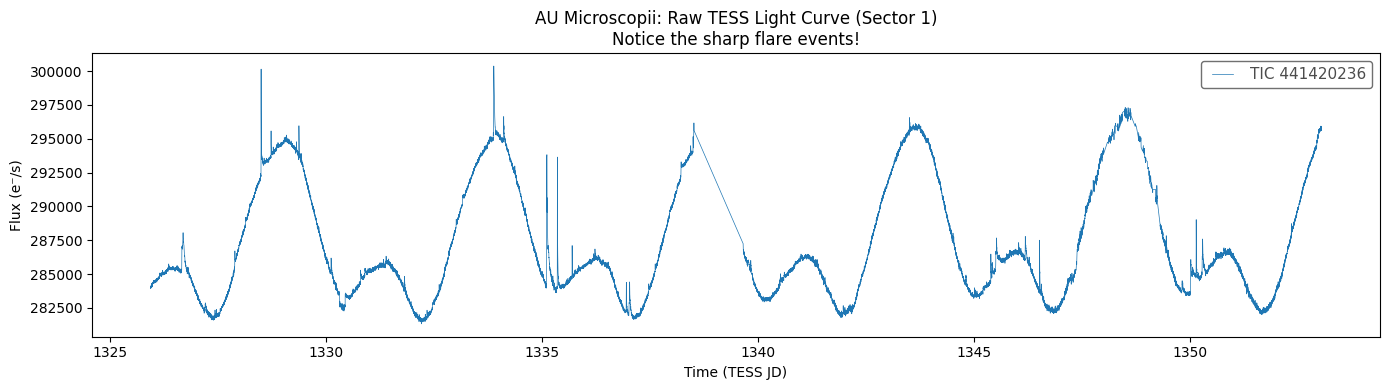

In [70]:
# Plot the raw light curve — you can already see flares as sharp spikes!
fig, ax = plt.subplots(figsize=(14, 4))
au_mic_lc.plot(ax=ax)
ax.set_ylabel('Flux (e⁻/s)')
ax.set_xlabel('Time (TESS JD)')
ax.set_title('AU Microscopii: Raw TESS Light Curve (Sector 1)\nNotice the sharp flare events!')
plt.tight_layout()

### 9.2 Flare Detection

**What to learn:** Develop a flare detection algorithm using statistical methods and lightkurve's data processing tools.

To systematically find all flares in a light curve, we use a two-step process:

1. **Detrend**: Remove long-term trends and the slow rotation of the star
2. **Threshold**: Identify points that deviate significantly from the baseline

This approach ensures we find real flares while avoiding false positives from instrumental noise.

In [71]:
# Step 1: Clean the light curve
# Remove NaN values and strongly outlying data
au_mic_clean = au_mic_lc.remove_nans()

# Step 2: Detrend to remove slow trends and stellar rotation
# We use a wide window to preserve flares but remove long-term drift
au_mic_detrended = au_mic_clean.flatten(window_length=1001, polyorder=2)

# Normalize to relative flux (1.0 = baseline)
au_mic_normalized = au_mic_detrended.normalize()

print(f"Original light curve: {len(au_mic_lc)} points")
print(f"After cleaning NaNs: {len(au_mic_clean)} points")
print(f"Normalized flux range: [{au_mic_normalized.flux.min():.4f}, {au_mic_normalized.flux.max():.4f}]")

# Convert time to numeric values for easier manipulation
au_mic_normalized_time = au_mic_normalized.time.jd  # Use Julian Day numeric values

Original light curve: 17802 points
After cleaning NaNs: 17687 points
Normalized flux range: [0.9875, 1.0345]


In [72]:
# Step 3: Detect flares using statistical threshold
# Calculate baseline and standard deviation
baseline_flux = np.median(au_mic_normalized.flux.value)
flux_std = np.std(au_mic_normalized.flux.value)

# Set threshold: 3 sigma above baseline (99.7% confidence for Gaussian)
threshold = 3.0
flare_threshold = baseline_flux + threshold * flux_std

# Find all points above threshold
flare_mask = au_mic_normalized.flux.value > flare_threshold

print(f"Baseline flux: {baseline_flux:.4f}")
print(f"Flux std dev: {flux_std:.6f}")
print(f"Flare threshold ({threshold}σ): {flare_threshold:.4f}")
print(f"Number of flaring pixels detected: {np.sum(flare_mask)}")

# Extract flare events (consecutive groups above threshold)
flare_events = np.where(flare_mask)[0]
print(f"Number of flare event groups: {len(np.unique(flare_events)) if len(flare_events) > 0 else 0}")

Baseline flux: 1.0000
Flux std dev: 0.002977
Flare threshold (3.0σ): 1.0089
Number of flaring pixels detected: 302
Number of flare event groups: 302


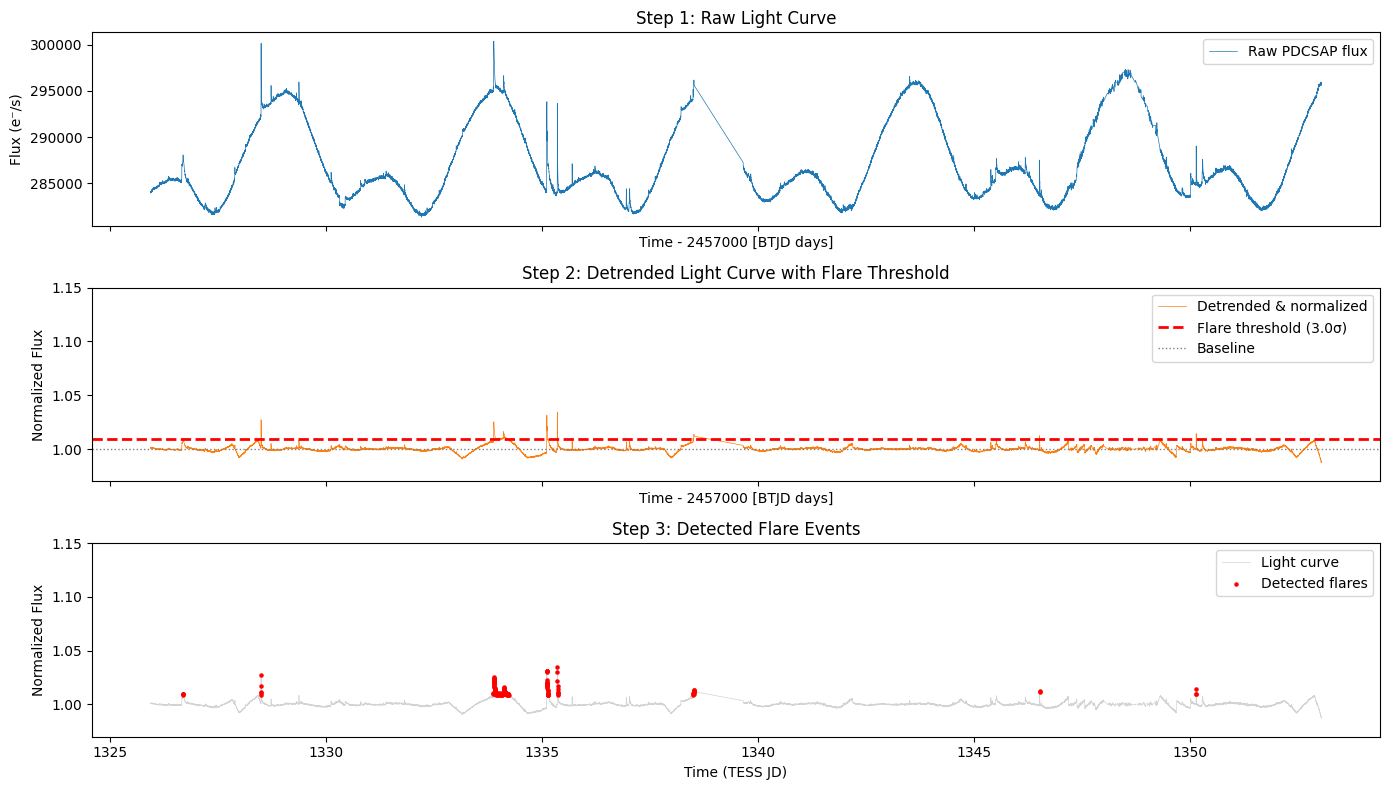

In [73]:
# Visualize the flare detection process
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Panel 1: Raw light curve
au_mic_lc.plot(ax=axes[0], label='Raw PDCSAP flux', color='C0')
axes[0].set_ylabel('Flux (e⁻/s)')
axes[0].set_title('Step 1: Raw Light Curve')
axes[0].legend()

# Panel 2: Detrended light curve
au_mic_normalized.plot(ax=axes[1], label='Detrended & normalized', color='C1')
axes[1].axhline(y=flare_threshold, color='red', linestyle='--', label=f'Flare threshold ({threshold}σ)', linewidth=2)
axes[1].axhline(y=baseline_flux, color='gray', linestyle=':', label='Baseline', linewidth=1)
axes[1].set_ylabel('Normalized Flux')
axes[1].set_title('Step 2: Detrended Light Curve with Flare Threshold')
axes[1].legend()
axes[1].set_ylim([0.97, 1.15])

# Panel 3: Detected flares highlighted
au_mic_normalized.plot(ax=axes[2], color='lightgray', label='Light curve')
au_mic_normalized[flare_mask].scatter(ax=axes[2], s=20, color='red', label='Detected flares', zorder=5)
axes[2].set_ylabel('Normalized Flux')
axes[2].set_xlabel('Time (TESS JD)')
axes[2].set_title('Step 3: Detected Flare Events')
axes[2].legend()
axes[2].set_ylim([0.97, 1.15])

plt.tight_layout()

### 9.3 Flare Characterization

**What to learn:** Extract and measure the physical properties of individual flare events.

Once we've detected flares, we want to characterize each one. For each flare event, we measure:
- **Rise time** (t_rise): Time from baseline to peak
- **Decay time** (t_decay): Time from peak back to baseline
- **Peak amplitude** (Δf_peak): Maximum excess flux above baseline
- **Total duration**: Time from start to end
- **Energy (ED)**: Equivalent Duration in units of baseline flux × time

The **Equivalent Duration** is particularly useful because it's a normalized energy measure that can be compared across different observations and stars.

In [74]:
# Identify individual flare events (contiguous groups)
# We'll label connected components (consecutive pixels above threshold)
from scipy import ndimage

labeled_flares, num_flares = ndimage.label(flare_mask)
print(f"Number of individual flare events: {num_flares}")

# Extract properties for each flare
flare_properties = []

for flare_id in range(1, num_flares + 1):
    flare_indices = np.where(labeled_flares == flare_id)[0]
    
    if len(flare_indices) < 2:  # Skip single-point events
        continue
    
    # Get time and flux for this flare (using numeric time values)
    flare_times = au_mic_normalized_time[flare_indices]
    flare_fluxes = au_mic_normalized.flux.value[flare_indices]
    
    # Find peak
    peak_idx_local = np.argmax(flare_fluxes)
    peak_flux = flare_fluxes[peak_idx_local]
    peak_time = flare_times[peak_idx_local]
    
    # Duration in minutes
    t_start = flare_times[0]
    t_end = flare_times[-1]
    duration = (t_end - t_start) * 24 * 60  # Convert days to minutes
    
    # Peak amplitude
    amplitude = peak_flux - baseline_flux
    
    # Equivalent Duration (sum of normalized excess)
    excess_flux = flare_fluxes - baseline_flux
    time_diff = np.diff(flare_times) * 24 * 60 * 60  # Convert to seconds
    ed = np.sum(excess_flux[:-1] / baseline_flux * time_diff) / 60  # In minutes
    
    flare_properties.append({
        'flare_id': flare_id,
        'start_time': t_start,
        'peak_time': peak_time,
        'end_time': t_end,
        'duration_min': duration,
        'peak_amplitude': amplitude,
        'equivalent_duration_s': ed * 60  # Convert back to seconds
    })

# Convert to DataFrame for easy analysis
flare_df = pd.DataFrame(flare_properties)
print(f"\nFlare Properties (first 10 events):")
print(flare_df.head(10).to_string())

Number of individual flare events: 20

Flare Properties (first 10 events):
   flare_id    start_time     peak_time      end_time  duration_min        peak_amplitude equivalent_duration_s
0         1  2.458327e+06  2.458327e+06  2.458327e+06      5.999987  0.009819351619581473     3.422486080888161
1         3  2.458329e+06  2.458329e+06  2.458329e+06      7.999971  0.027294635935010136     8.112533990834176
2         4  2.458334e+06  2.458334e+06  2.458334e+06     75.999313    0.0253652916142606      69.0331562836397
3         6  2.458334e+06  2.458334e+06  2.458334e+06      5.999946  0.009564948822655905    3.3766722686083916
4         7  2.458334e+06  2.458334e+06  2.458334e+06    353.996743  0.016269301938957925    215.46682042314433
5         8  2.458334e+06  2.458334e+06  2.458334e+06     31.999700  0.009617546342073569    17.995242169117724
6         9  2.458334e+06  2.458334e+06  2.458334e+06      3.999963   0.00950555565405553    2.2778945019204855
7        13  2.458335e+06  2.

### 9.4 Flare Rates and Equivalent Duration

**What to learn:** Calculate statistical measures of flaring activity to characterize stellar activity levels.

Two key statistics describe a star's flaring activity:

1. **Flare Rate**: Number of flares per day
   - Allows comparison across observations of different lengths
   - Helps characterize stellar activity levels

2. **Cumulative Equivalent Duration (CED)**: Total flare energy over the observation
   - Measures the total energy budget in flares
   - Useful for understanding stellar dynamos and magnetic energy release
   
The equation for Equivalent Duration of a single flare is:
$$ED = \int \frac{f(t) - f_{baseline}}{f_{baseline}} dt$$

Where the integral is over the flare duration.

In [75]:
# Calculate flare statistics
observation_duration_days = au_mic_normalized_time[-1] - au_mic_normalized_time[0]
num_flares_detected = len(flare_df)

# Flare rate: flares per day
flare_rate = num_flares_detected / observation_duration_days

# Cumulative Equivalent Duration
cumulative_ed = flare_df['equivalent_duration_s'].sum()

# Statistics
mean_amplitude = flare_df['peak_amplitude'].mean()
max_amplitude = flare_df['peak_amplitude'].max()
mean_duration = flare_df['duration_min'].mean()
mean_ed = flare_df['equivalent_duration_s'].mean()

print("=" * 60)
print("AU MICROSCOPII FLARE STATISTICS (TESS Sector 1)")
print("=" * 60)
print(f"Observation duration: {observation_duration_days:.2f} days")
print(f"Number of flares detected: {num_flares_detected}")
print(f"Flare rate: {flare_rate:.2f} flares/day")
print()
print("Flare Properties:")
print(f"  Mean peak amplitude: {mean_amplitude:.4f} (normalized)")
print(f"  Max peak amplitude: {max_amplitude:.4f} (normalized)")
print(f"  Mean duration: {mean_duration:.2f} minutes")
print(f"  Mean equivalent duration: {mean_ed:.1f} seconds")
print()
print(f"Cumulative Equivalent Duration: {cumulative_ed:.1f} seconds")
print(f"Cumulative ED per day: {cumulative_ed/observation_duration_days:.1f} s/day")
print("=" * 60)

AU MICROSCOPII FLARE STATISTICS (TESS Sector 1)
Observation duration: 27.10 days
Number of flares detected: 13
Flare rate: 0.48 flares/day

Flare Properties:
  Mean peak amplitude: 0.0173 (normalized)
  Max peak amplitude: 0.0345 (normalized)
  Mean duration: 43.69 minutes
  Mean equivalent duration: 30.9 seconds

Cumulative Equivalent Duration: 402.2 seconds
Cumulative ED per day: 14.8 s/day


### 9.5 Visualizing Flares

**What to learn:** Create publication-quality visualizations of flare data and statistics.

Effective visualization is crucial for communicating your results. We'll create three plots:
1. Time series with all flares highlighted
2. Amplitude and duration distribution
3. Cumulative equivalent duration over time

/var/folders/v0/v_qnst7n3hn5fdcjh69y2qvm0000gn/T/ipykernel_72052/2113485491.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


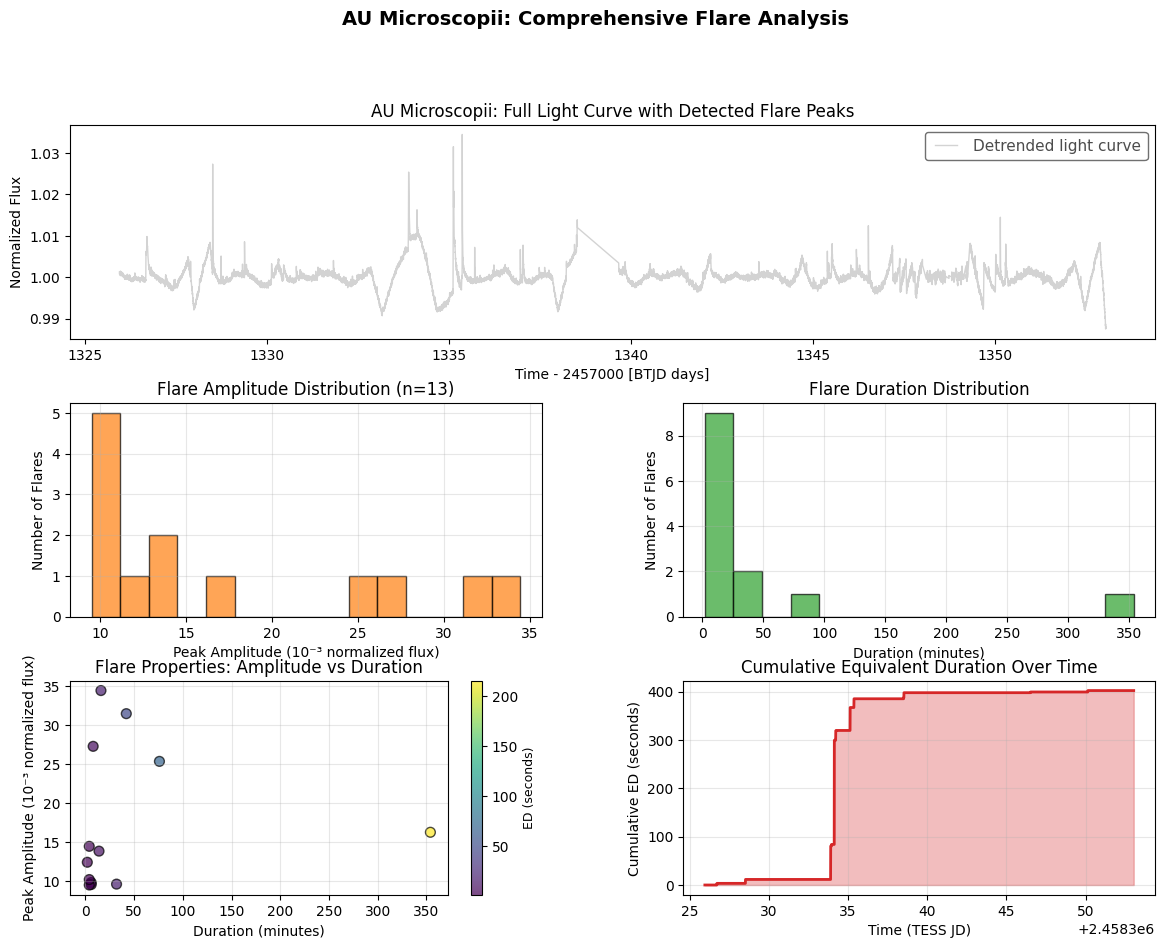

In [79]:
# Create comprehensive flare visualization
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Panel 1: Full light curve with flares marked
ax1 = fig.add_subplot(gs[0, :])
au_mic_normalized.plot(ax=ax1, color='lightgray', label='Detrended light curve', linewidth=1)
# au_mic_normalized.plot(ax=axes[1], label='Detrended & normalized', color='C1')
# for idx, row in flare_df.iterrows():
#     ax1.axvline(row['peak_time'], color='red', alpha=0.3, linewidth=1)
ax1.set_ylabel('Normalized Flux')
ax1.set_title('AU Microscopii: Full Light Curve with Detected Flare Peaks')
# ax1.set_ylim([0.98, 1.12])

# Panel 2: Flare amplitude distribution
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(flare_df['peak_amplitude'] * 1000, bins=15, color='C1', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Peak Amplitude (10⁻³ normalized flux)')
ax2.set_ylabel('Number of Flares')
ax2.set_title(f'Flare Amplitude Distribution (n={len(flare_df)})')
ax2.grid(True, alpha=0.3)

# Panel 3: Flare duration distribution
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(flare_df['duration_min'], bins=15, color='C2', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Duration (minutes)')
ax3.set_ylabel('Number of Flares')
ax3.set_title('Flare Duration Distribution')
ax3.grid(True, alpha=0.3)

# Panel 4: Amplitude vs Duration
ax4 = fig.add_subplot(gs[2, 0])
scatter = ax4.scatter(flare_df['duration_min'], flare_df['peak_amplitude'] * 1000, 
                      c=flare_df['equivalent_duration_s'], cmap='viridis', s=50, alpha=0.7, edgecolors='black')
ax4.set_xlabel('Duration (minutes)')
ax4.set_ylabel('Peak Amplitude (10⁻³ normalized flux)')
ax4.set_title('Flare Properties: Amplitude vs Duration')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('ED (seconds)', fontsize=9)
ax4.grid(True, alpha=0.3)

# Panel 5: Cumulative Equivalent Duration
ax5 = fig.add_subplot(gs[2, 1])
# Create array of cumulative ED
cumulative_values = []
for t in au_mic_normalized_time:
    cum = flare_df[flare_df['peak_time'] <= t]['equivalent_duration_s'].sum()
    cumulative_values.append(cum)

ax5.plot(au_mic_normalized_time, cumulative_values, color='C3', linewidth=2)
ax5.fill_between(au_mic_normalized_time, cumulative_values, alpha=0.3, color='C3')
ax5.set_xlabel('Time (TESS JD)')
ax5.set_ylabel('Cumulative ED (seconds)')
ax5.set_title('Cumulative Equivalent Duration Over Time')
ax5.grid(True, alpha=0.3)

plt.suptitle('AU Microscopii: Comprehensive Flare Analysis', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

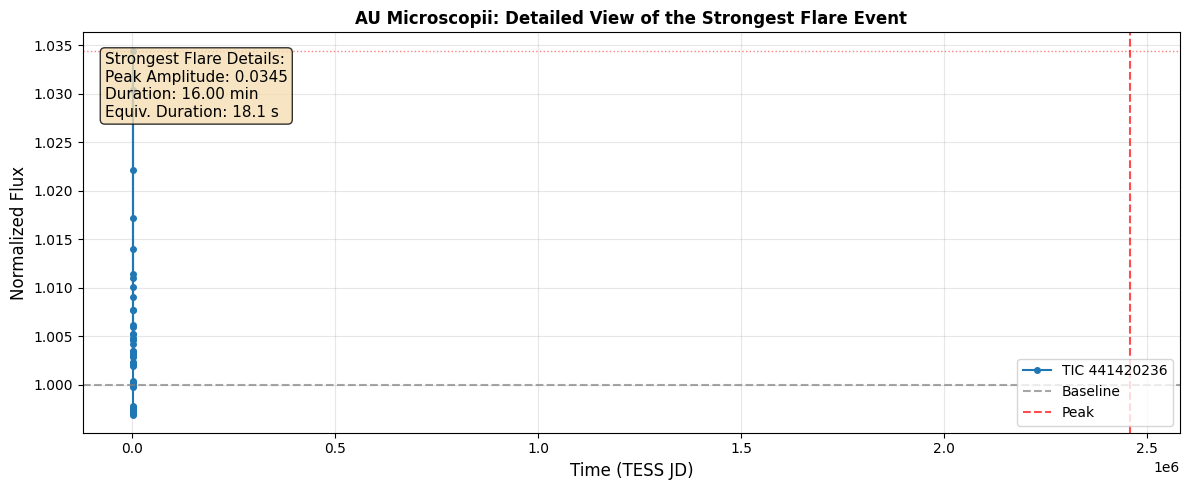

In [78]:
# Zoom in on a single prominent flare to show structure
# Find the strongest flare
strongest_flare_idx = flare_df['peak_amplitude'].idxmax()
strongest_flare = flare_df.iloc[strongest_flare_idx]

# Extract time window around the flare (±1 hour)
flare_time = strongest_flare['peak_time']
time_window = 1 / 24  # 1 hour in days
mask_zoom = (au_mic_normalized_time >= flare_time - time_window) & \
            (au_mic_normalized_time <= flare_time + time_window)

# Plot zoomed flare
fig, ax = plt.subplots(figsize=(12, 5))
au_mic_normalized[mask_zoom].plot(ax=ax, marker='o', markersize=4, linewidth=1.5, color='C0')

# Add annotations
ax.axhline(y=baseline_flux, color='gray', linestyle='--', linewidth=1.5, label='Baseline', alpha=0.7)
ax.axvline(x=strongest_flare['peak_time'], color='red', linestyle='--', linewidth=1.5, label='Peak', alpha=0.7)
ax.axhline(y=strongest_flare['peak_amplitude'] + baseline_flux, color='red', linestyle=':', 
           linewidth=1, alpha=0.5)

# Annotate with measurements
ax.text(0.02, 0.95, f"Strongest Flare Details:\n" +
                     f"Peak Amplitude: {strongest_flare['peak_amplitude']:.4f}\n" +
                     f"Duration: {strongest_flare['duration_min']:.2f} min\n" +
                     f"Equiv. Duration: {strongest_flare['equivalent_duration_s']:.1f} s",
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_ylabel('Normalized Flux', fontsize=12)
ax.set_xlabel('Time (TESS JD)', fontsize=12)
ax.set_title('AU Microscopii: Detailed View of the Strongest Flare Event', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Glossary: Key Concepts in Light Curve Analysis

**Aperture Mask**: A spatial mask defining which pixels contribute to the light curve. Pipeline apertures are automatically generated; custom apertures can be created using `create_threshold_mask()` or manual selection.

**Baseline Flux**: The average or median flux level of a light curve, used as a reference point for measuring deviations (e.g., flares, transits).

**BKJD (Barycentric Kepler Julian Date)**: Time reference system used by Kepler mission. Days since January 1, 2009, 00:00 UT, with corrections for Earth's motion around the Sun.

**Cadence**: The time interval between consecutive observations. High-cadence data (e.g., 2 min) is better for detecting rapid events like flares; long-cadence (e.g., 30 min) is suitable for slower phenomena like transits.

**Detrending**: Process of removing instrumental trends and stellar rotation from light curves while preserving astrophysical signals. Methods include polynomial fitting, Savitzky-Golay filtering, and spline models.

**Equivalent Duration (ED)**: A normalized measure of flare energy, defined as the integral of (excess_flux / baseline_flux) over time. Units: seconds or minutes. Allows comparison of flare energies across different observations.

**FFI (Full-Frame Image)**: TESS observations of entire sectors (~2000×2000 pixels). Used to create custom target pixel cutouts via TESSCut.

**Flare**: Sudden, transient brightening caused by magnetic reconnection in a star's atmosphere. Characterized by rapid rise times (seconds to minutes) and exponential decay. Common on young and active low-mass stars.

**Flux**: Brightness of the target, measured in electrons per second (e⁻/s) or as a normalized fraction of baseline.

**Folding**: Process of aligning observations to a known period and stacking them together to reveal periodic signals. Data aligned in "phase" space (0 to 1, where 1 = one period).

**PDCSAP (Pre-search Data Conditioning SAP)**: Pipeline-corrected light curve with systematic effects (spacecraft motion, thermal drifts, etc.) removed. Preferred for most science analyses.

**Period**: Time for one complete cycle of a periodic phenomenon. For transits: orbital period. For pulsating stars: oscillation period. For rotation: rotational period.

**Periodogram**: A statistical tool showing the power (contribution to overall variance) at each frequency (or period). Peaks indicate periodic signals in the data.

**SAP (Simple Aperture Photometry)**: Minimal-processing light curve containing mostly raw flux from the specified aperture, with few systematic corrections.

**Sector**: TESS observing campaign (~27 days). Each sector observes a different ~24° × 96° region of sky. The spacecraft rotates between sectors.

**TIC (TESS Input Catalog)**: Identifier for sources in the TESS mission (e.g., TIC 198900877 for AU Microscopii).

**TPF (Target Pixel File)**: Raw 2D image data for a target, with one image per cadence. Contains all pixel-level information needed to custom-extract light curves.

**Transit**: Periodic dip in brightness when an exoplanet crosses the star's disk (from our perspective). Typical depths: 0.01% (Earth-sized) to 1% (Jupiter-sized).

**Normalization**: Scaling flux values to have a baseline of 1.0, making relative changes more interpretable.

## Next Steps & Additional Resources

### What You've Learned

Congratulations! You now know how to:
- **Search and download** light curve data from TESS, Kepler, and K2 using MAST
- **Process and clean** raw light curve data (detrending, outlier removal, normalization)
- **Detect periodic signals** using Lomb-Scargle and Box Least Squares periodograms
- **Find and characterize** stellar flares with flare rates and equivalent durations
- **Create publication-quality** visualizations of astronomical data

### Suggested Next Steps

1. **Try other targets**: Experiment with different stars using the search functions. Look for transit signals in planetary systems or oscillations in pulsating variables.

2. **Advanced flare analysis**: Explore methods for:
   - Fitting exponential decay models to flares
   - Calculating flare energies in physical units (erg/cm²)
   - Studying flare frequency distributions and power laws

3. **Systematic studies**: Compare flaring rates across multiple sectors or missions to study stellar activity cycles.

4. **Machine learning**: Use supervised learning to automate flare detection or classify different types of stellar variability.

### Resources

- **Lightkurve Documentation**: http://docs.lightkurve.org/
- **Lightkurve GitHub**: https://github.com/KeplerGO/lightkurve
- **MAST Archive**: https://mast.stsci.edu/
- **Astropy Documentation**: https://docs.astropy.org/
- **TESS Mission Page**: https://tess.mit.edu/
- **Kepler Mission Page**: https://www.nasa.gov/kepler/

### References

- Davenport et al. (2014) - Standard flare parametrization and equivalent duration
- Hawley et al. (2014) - Kepler flare rates on M dwarfs
- Ilin et al. (2021) - TESS observations of stellar flares

### Glossary

- **Aperture**: The region of pixels summed to create a light curve
- **BKJD**: Barycentric Kepler Julian Day (Kepler-specific time format)
- **Cadence**: The time interval between observations
- **Detrending**: Removing long-term instrumental drifts while preserving astrophysical signals
- **Equivalent Duration (ED)**: Integrated excess flux, a measure of flare energy
- **Flare**: Sudden release of magnetic energy in a star's atmosphere
- **Folding**: Aligning periodic observations to a common reference phase
- **PDCSAP**: Pre-search Data Conditioning SAP - pipeline-corrected flux with systematics removed
- **Periodogram**: A plot showing power vs. frequency/period, used to find periodic signals
- **SAP**: Simple Aperture Photometry - basic pipeline flux
- **TPF**: Target Pixel File - raw 2D image data from the telescope